In [2]:
import os
os.chdir("/users/ffbence/dose")

In [3]:
dataPath = "data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training"
sample = "1ABB011"

In [4]:
!ls

cache.log	 data	    sample_script_runner.sh  train.py
configs		 notebooks  scripts		     train.sh
create_cache.py  README.md  start_notebook.sh	     utils


In [4]:
import torch
import torch.nn as nn
from omegaconf import OmegaConf

In [5]:
from scripts.metrics import BeamMaskedMAELoss, IDDCurveLoss, Stratified_plan_level_MAE, GammaLoss

# Eda

In [6]:
def test_beam_masked_mae():
    torch.manual_seed(0)
    B, N, D, H, W = 2, 3, 16, 64, 64

    target = torch.rand(B, N, D, H, W)
    pred   = target + 0.05 * torch.randn(B, N, D, H, W)

    loss_fn = BeamMaskedMAELoss()
    loss    = loss_fn(pred, target)
    print(f"Loss (mean, 3D): {loss.item():.6f}")

    # reduction='none' → per-beam tensor
    per_beam = BeamMaskedMAELoss(reduction="none")(pred, target)
    print(f"Per-beam shape: {per_beam.shape}")   # (2, 3)
    print(f"Per-beam values:\n{per_beam}")

    # 2-D spatial (e.g. slice-wise)
    target_2d = torch.rand(B, N, H, W)
    pred_2d   = target_2d + 0.05 * torch.randn(B, N, H, W)
    loss_2d   = loss_fn(pred_2d, target_2d)
    print(f"Loss (mean, 2D): {loss_2d.item():.6f}")

    # Zero-dose beam edge case
    target_zero          = torch.rand(B, N, D, H, W)
    target_zero[:, 0, :] = 0.0   # first beam has zero gt dose
    pred_zero            = torch.rand(B, N, D, H, W)
    loss_zero            = loss_fn(pred_zero, target_zero)
    print(f"Loss with one zero-dose beam: {loss_zero.item():.6f}")

test_beam_masked_mae()

Loss (mean, 3D): 0.039881
Per-beam shape: torch.Size([2, 3])
Per-beam values:
tensor([[0.0400, 0.0398, 0.0399],
        [0.0399, 0.0397, 0.0399]])
Loss (mean, 2D): 0.039788
Loss with one zero-dose beam: 16665793.000000


In [7]:
def test_iid():
    import torch
 
    torch.manual_seed(42)
    B, N, H, W = 2, 3, 64, 64
 
    # ---- basic forward pass ----
    target = torch.rand(B, N, H, W)
    pred   = target + 0.05 * torch.randn(B, N, H, W)
 
    loss_fn = IDDCurveLoss(beam_dim=-1)           # depth = W axis
    loss    = loss_fn(pred, target)
    print(f"Loss (mean, beam_dim=-1): {loss.item():.6f}")
 
    loss_fn0 = IDDCurveLoss(beam_dim=0)           # depth = H axis
    loss0    = loss_fn0(pred, target)
    print(f"Loss (mean, beam_dim= 0): {loss0.item():.6f}")
 
    # ---- perfect prediction → loss should be ~0 ----
    loss_perfect = loss_fn(target, target)
    print(f"Loss (perfect pred):      {loss_perfect.item():.6f}")
 
    # ---- reduction='none' → per-beam ----
    per_beam = IDDCurveLoss(beam_dim=-1, reduction="none")(pred, target)
    print(f"Per-beam shape: {per_beam.shape}")    # (B, N) = (2, 3)
    print(f"Per-beam values:\n{per_beam}")
 
    # ---- single-channel total dose (B, H, W) ----
    target_2d = torch.rand(B, H, W)
    pred_2d   = target_2d + 0.05 * torch.randn(B, H, W)
    loss_2d   = IDDCurveLoss(beam_dim=-1)(pred_2d, target_2d)
    print(f"Loss (single-channel 2D): {loss_2d.item():.6f}")
 
    # ---- zero ground truth edge case ----
    target_z  = torch.zeros(B, N, H, W)
    pred_z    = torch.rand(B, N, H, W)
    loss_z    = loss_fn(pred_z, target_z)
    print(f"Loss (zero gt):           {loss_z.item():.6f}")   # should be large but finite

test_iid()

Loss (mean, beam_dim=-1): 0.010627
Loss (mean, beam_dim= 0): 0.011384
Loss (perfect pred):      0.000000
Per-beam shape: torch.Size([2, 3])
Per-beam values:
tensor([[0.0098, 0.0104, 0.0091],
        [0.0105, 0.0122, 0.0116]])
Loss (single-channel 2D): 0.010557
Loss (zero gt):           3219645184.000000


In [8]:
def test_local_gamma_3d():
    print("Running 3D Local Gamma Index Tests...")
    
    # Initialize evaluator with 1mm isotropic spacing
    evaluator = GammaLoss(voxel_spacing=(1.0, 1.0, 1.0))
    device = torch.device("cpu") # Can change to "cuda" if testing on GPU
    evaluator.to(device)

    # Base Ground Truth: A 5x5x5 volume with 100.0 dose everywhere
    # 1% dose tolerance = 1.0
    gt_base = torch.full((5, 5, 5), 100.0, device=device)

    # ---------------------------------------------------------
    # Test 1: Perfect Match
    # ---------------------------------------------------------
    pred_perfect = gt_base.clone()
    pass_rate = evaluator.local_gamma_3d(pred_perfect, gt_base).item()
    assert pass_rate == 1.0, f"Test 1 Failed: Perfect match should yield 1.0, got {pass_rate}"
    print("  [PASS] Test 1: Perfect Match")

    # ---------------------------------------------------------
    # Test 2: Borderline Dose Pass (+1.0%)
    # ---------------------------------------------------------
    # Every voxel has exactly +1% error (101.0). Spatial distance is 0mm.
    # Gamma = sqrt((0/1mm)^2 + (1.0/1.0)^2) = 1.0 -> PASS
    pred_borderline = gt_base + 1.0
    pass_rate = evaluator.local_gamma_3d(pred_borderline, gt_base).item()
    assert pass_rate == 1.0, f"Test 2 Failed: Borderline 1% difference should pass (1.0), got {pass_rate}"
    print("  [PASS] Test 2: Borderline Dose Pass (Exactly 1% diff)")

    # ---------------------------------------------------------
    # Test 3: Definite Dose Fail (+2.0%)
    # ---------------------------------------------------------
    # Every voxel has +2% error (102.0). 
    # Gamma = sqrt(0 + (2.0/1.0)^2) = 2.0 -> FAIL
    pred_fail = gt_base + 2.0
    pass_rate = evaluator.local_gamma_3d(pred_fail, gt_base).item()
    assert pass_rate == 0.0, f"Test 3 Failed: 2% difference should fail (0.0), got {pass_rate}"
    print("  [PASS] Test 3: Definite Dose Fail (>1% diff)")

    # ---------------------------------------------------------
    # Test 4: Pure Spatial Shift (Distance-to-Agreement)
    # ---------------------------------------------------------
    # Create a volume mostly 0, with a single "hot" voxel of 100.0
    gt_spatial = torch.zeros((5, 5, 5), device=device)
    gt_spatial[2, 2, 2] = 100.0 
    
    # Pred is shifted exactly 1 voxel (1.0 mm) along the X axis
    pred_spatial = torch.zeros((5, 5, 5), device=device)
    pred_spatial[2, 2, 3] = 100.0 
    
    # For the GT voxel at (2,2,2), the algorithm will search its 1mm neighborhood,
    # find the 100.0 at (2,2,3) in the shifted tensor math, and pass it.
    pass_rate = evaluator.local_gamma_3d(pred_spatial, gt_spatial).item()
    assert pass_rate == 1.0, f"Test 4 Failed: 1mm spatial shift should pass (1.0), got {pass_rate}"
    print("  [PASS] Test 4: Distance-to-Agreement (1mm Shift)")

    # ---------------------------------------------------------
    # Test 5: 10% Threshold Exclusion
    # ---------------------------------------------------------
    # Setup GT where one half is high dose (100.0), one half is low dose (5.0)
    # The maximum is 100.0, so the 10% threshold is 10.0.
    # Therefore, the 5.0 region should NOT be evaluated.
    gt_thresh = torch.zeros((4, 4, 4), device=device)
    gt_thresh[:, :, :2] = 100.0  # High dose region (Evaluated)
    gt_thresh[:, :, 2:] = 5.0    # Low dose region (Ignored)

    # We make the prediction PERFECT in the high dose region, 
    # but TERRIBLE in the low dose region (+10 dose error, which is 200% error locally).
    pred_thresh = gt_thresh.clone()
    pred_thresh[:, :, 2:] += 10.0 

    # Because the terrible predictions are below the 10% threshold, they should be ignored.
    # The pass rate should still be 100% (1.0).
    pass_rate = evaluator.local_gamma_3d(pred_thresh, gt_thresh).item()
    assert pass_rate == 1.0, f"Test 5 Failed: Errors below 10% threshold should be ignored, got {pass_rate}"
    print("  [PASS] Test 5: 10% Dose Threshold Exclusion")

    print("\nAll 3D Local Gamma Tests Passed Successfully! ✅")

test_local_gamma_3d()

Running 3D Local Gamma Index Tests...
  [PASS] Test 1: Perfect Match
  [PASS] Test 2: Borderline Dose Pass (Exactly 1% diff)
  [PASS] Test 3: Definite Dose Fail (>1% diff)
  [PASS] Test 4: Distance-to-Agreement (1mm Shift)
  [PASS] Test 5: 10% Dose Threshold Exclusion

All 3D Local Gamma Tests Passed Successfully! ✅


# Data Loader help

In [9]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    ScaleIntensityRanged)

import torch
from omegaconf import OmegaConf
import os


## Json Creation

In [38]:
import json
from monai.transforms import MapTransform, Compose, LoadImaged, EnsureChannelFirstd, Spacingd, CenterSpatialCropd
import nibabel as nib
import numpy as np
from monai.data import Dataset, DataLoader

In [39]:
def create_doserad_dataset(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    dataset_list = []
    base_dir = os.path.dirname(json_path)
    ct_path = os.path.join(base_dir, "image", "ct.mha")
    
    for beam in data.get('beams', []):
        beam_idx = beam['beam_idx']
        
        for ray in beam.get('rays', []):
            ray_idx = ray['ray_idx']
            ray_source = ray['ray_source'] # Expected format: [x, y, z] in mm
            
            for beamlet in ray.get('beamlets', []):
                beamlet_idx = beamlet['beamlet_idx']
                energy = beamlet['energy']
                
                # Reconstruct the specific dose filename
                dose_filename = f"Dose_B{beam_idx}_R{ray_idx}_L{beamlet_idx}.mha"
                dose_path = os.path.join(base_dir, "dose", dose_filename)
                
                if os.path.exists(dose_path) and os.path.exists(ct_path):
                    dataset_list.append({
                        "ct": ct_path,
                        "gt_dose": dose_path,
                        "ray_source_phys": ray_source,
                        "energy": energy
                    })
                    
    return dataset_list

In [107]:
jsonPaths[0].split("/")[-2]

'1ABB041'

In [108]:
import random
from collections import defaultdict

def create_split_datasets(json_paths, val_split=0.1):

    # 1. Group data by patient/sample
    patient_data = defaultdict(list)
    sample_names = [json_path.split("/")[-2] for json_path in json_paths]
    
    for i, json_path in enumerate(json_paths):        
        # Use your parser function (from earlier) for this specific sample
        sample_dicts = create_doserad_dataset(json_path)
        patient_data[sample_names[i]].extend(sample_dicts)
        
    # 2. Shuffle the patients, NOT the individual beamlets
    random.seed(42) # Exact reproducibility
    random.shuffle(sample_names)
    
    # 3. Calculate split index based on the number of patients
    split_idx = int(len(sample_names) * (1 - val_split))
    train_patients = sample_names[:split_idx]
    val_patients = sample_names[split_idx:]
    
    # 4. Flatten back into MONAI-ready lists
    train_list = []
    for p in train_patients:
        train_list.extend(patient_data[p])
        
    val_list = []
    for p in val_patients:
        val_list.extend(patient_data[p])
        
    print(f"Training Samples: {len(train_list)} (from {len(train_patients)} patients)")
    print(f"Validation Samples: {len(val_list)} (from {len(val_patients)} patients)")
    
    return train_list, val_list

In [40]:
dataset_list = create_doserad_dataset("/users/ffbence/dose/data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB006/1ABB006.json")

In [102]:
import glob
jsonPaths = glob.glob('data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/*/*.json')

In [113]:
train_list, val_list = create_split_datasets(jsonPaths)

Training Samples: 72360 (from 67 patients)
Validation Samples: 8639 (from 8 patients)


In [116]:
train_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in train_list
]

val_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in val_list
]

In [121]:
json.dump(train_list, open("data/train.json", "w"), indent=4)
json.dump(val_list, open("data/val.json", "w"), indent=4)

In [94]:
dataset_list = [create_doserad_dataset(json_path) for json_path in jsonPaths]
dataset_list = [item for sublist in dataset_list for item in sublist]  # Flatten the list of lists

In [98]:
dataset_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in dataset_list
]

In [99]:
dataset_list[0]

{'ct': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB041/image/ct.mha',
 'gt_dose': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB041/dose/Dose_B0_R0_L0.mha',
 'condition': [-51.56999969482422,
  -1037.4300537109375,
  17.350000381469727,
  164.4532012939453]}

In [100]:
json.dump(dataset_list, open("dataset_list.json", "w"), indent=4)

In [41]:
class ExtractSlabAroundZ(MapTransform):
    def __init__(self, keys, source_key="ray_source_phys", margin_slices=10, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.source_key = source_key
        self.margin_slices = margin_slices

    def __call__(self, data):
        d = dict(data)
        ray_source_phys = d[self.source_key] # [x, y, z]
        
        for key in self.key_iterator(d):
            img = d[key]
            
            # Extract the 4x4 affine matrix from the MONAI MetaTensor
            affine = img.affine.cpu().numpy()
            
            # Invert the affine to map physical coordinates back to voxel coordinates
            inv_affine = np.linalg.inv(affine)
            voxel_coords = nib.affines.apply_affine(inv_affine, ray_source_phys)
            
            # Assuming standard spatial arrangement where Z is the 3rd spatial dimension (idx 2)
            # Shape is [C, H, W, Z] after EnsureChannelFirstd
            z_voxel = int(np.round(voxel_coords[2]))
            
            z_min = max(0, z_voxel - self.margin_slices)
            z_max = min(img.shape[3], z_voxel + self.margin_slices + 1)
            
            # Slice the tensor. MONAI MetaTensors automatically update their affine 
            # metadata under the hood when sliced like this.
            d[key] = img[:, :, :, z_min:z_max]
            
        return d

In [42]:
train_transforms = Compose([
    LoadImaged(keys=["ct", "gt_dose"]),
    EnsureChannelFirstd(keys=["ct", "gt_dose"]),
    # Extract +/- 10 slices based on the physical ray location
    ExtractSlabAroundZ(keys=["ct", "gt_dose"], source_key="ray_source_phys", margin_slices=10),
    # Resample the extracted slabs to a fixed 1x1x1 mm resolution
    Spacingd(keys=["ct", "gt_dose"], pixdim=(1.0, 1.0, 1.0), mode="trilinear"),
    CenterSpatialCropd(keys=["ct", "gt_dose"], roi_size=(256, 256, 40))
])

In [49]:
sample_ds = Dataset(data=dataset_list, transform=train_transforms)
train_loader = DataLoader(sample_ds,batch_size=4,shuffle=True, num_workers=0)

In [57]:
len(dataset_list)

1080

In [58]:

for i, batch in enumerate(train_loader):
    print(f"CT shape: {batch['ct'].shape}")
    print(f"GT Dose shape: {batch['gt_dose'].shape}")
    print(f"Energies: {batch['energy']}")
    break

CT shape: torch.Size([4, 1, 256, 256, 40])
GT Dose shape: torch.Size([4, 1, 256, 256, 40])
Energies: tensor([131.5856, 164.4532, 106.3045, 161.4017], dtype=torch.float64)


In [61]:
batch = next(iter(train_loader))

In [62]:
ct = batch['ct']
gt = batch['gt_dose']

In [63]:
from monai.visualize import matshow3d

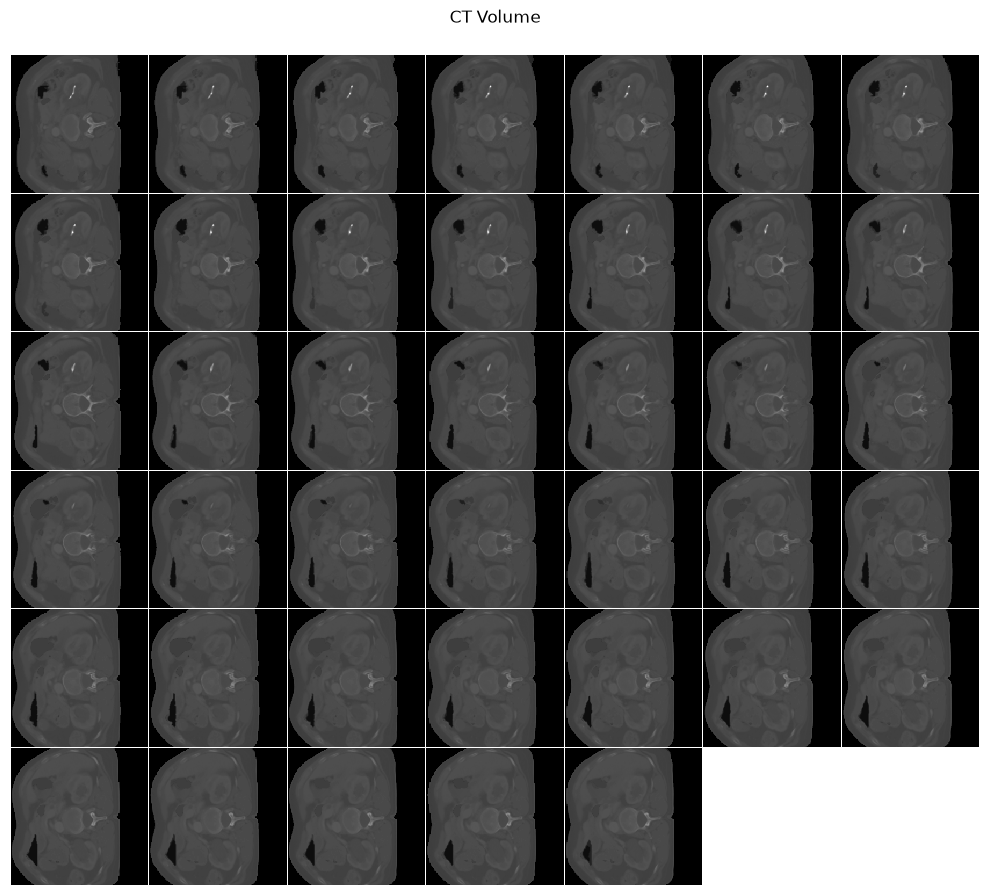

(<Figure size 1000x1000 with 1 Axes>,
 array([[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, -1024., -1024., ..., -1024., -1024.,    nan],
        [   nan, -1024., -1024., ..., -1024., -1024.,    nan],
        ...,
        [   nan, -1024., -1024., ...,    nan,    nan,    nan],
        [   nan, -1024., -1024., ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan]],
       shape=(1548, 1806), dtype=float32))

In [65]:
matshow3d(ct[0, 0], title="CT Volume", frame_dim=2, show=True,cmap='gray')

In [74]:
gt[0,0]

metatensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 

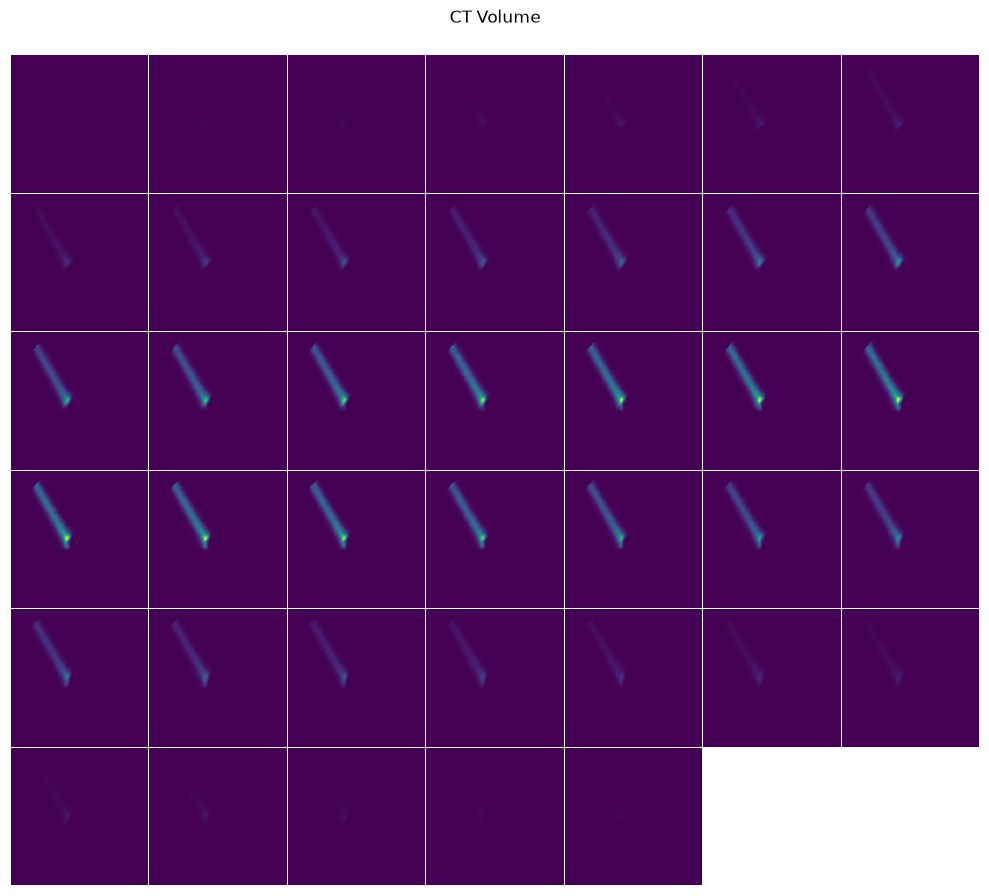

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(1548, 1806), dtype=float32))

In [77]:
matshow3d(gt[3, 0], title="CT Volume", frame_dim=2, show=True)

# Data Loader

In [5]:
from scripts.data_loader import get_loaders

In [6]:
train_loader, val_loader = get_loaders(hw = "atlasz")

In [7]:
batch = next(iter(train_loader))

In [17]:
batch['ct'].shape

torch.Size([64, 1, 256, 256, 64])

In [15]:
batch['condition'].shape

AttributeError: 'list' object has no attribute 'shape'

In [14]:
batch['condition'][0].shape

torch.Size([64])